In [4]:
import sys
import os

PROJECT_ROOT = os.path.abspath("..")
sys.path.insert(0, PROJECT_ROOT)

In [5]:
import os
import torch
import pandas as pd
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

from joblib import dump, load
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

from torch.utils.data import DataLoader, TensorDataset
import pytorch_lightning as pl
from pytorch_lightning.loggers import CSVLogger, TensorBoardLogger
from pytorch_lightning.callbacks import EarlyStopping

from core.data_module import TabRDataModule
from core.TabR import LitTabR


In [3]:
def visualize_results(
    model_dir,
    class_names=("tidak", "anxiety")
):
    model_dir = model_dir.rstrip("/")

    cm_files = {
        "Internal": os.path.join(model_dir, "cm_internal.png"),
        "External": os.path.join(model_dir, "cm_external.png"),
    }

    report_files = {
        "Internal": os.path.join(model_dir, "report_internal.csv"),
        "External": os.path.join(model_dir, "report_external.csv"),
    }

    # ===== SHOW CONFUSION MATRICES =====
    for name, path in cm_files.items():
        if not os.path.exists(path):
            print(f"❌ Missing {path}")
            continue

        img = mpimg.imread(path)
        plt.figure(figsize=(5, 4))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"CNN {name} Confusion Matrix")
        plt.show()

    # ===== PRINT CLASSIFICATION REPORTS =====
    for name, path in report_files.items():
        if not os.path.exists(path):
            print(f"❌ Missing {path}")
            continue

        df = pd.read_csv(path, index_col=0)

        print(f"\n=== {name.upper()} CLASSIFICATION REPORT (PERCENT) ===")
        print(f"{'Class':12s} {'Precision':>10s} {'Recall':>10s} {'F1':>10s} {'Support':>9s}")

        for i, cls in enumerate(class_names):
            p, r, f, s = df.loc[str(i), ["precision", "recall", "f1-score", "support"]]
            print(f"{cls:12s} {p*100:9.2f}% {r*100:9.2f}% {f*100:9.2f}% {int(s):9d}")

        acc = df.loc["accuracy", "precision"]
        print(f"Accuracy: {acc*100:.2f}%")

In [4]:
def plot_lightning_metrics(metrics_csv):
    import pandas as pd
    import matplotlib.pyplot as plt

    df = pd.read_csv(metrics_csv)

    if "epoch" not in df.columns:
        raise ValueError("Kolom epoch tidak ada")

    df_epoch = (
        df.sort_values("step")
          .groupby("epoch", as_index=False)
          .last()
    )

    # =====================
    # LOSS
    # =====================
    plt.figure()

    if "train_loss" in df_epoch:
        plt.plot(df_epoch["epoch"], df_epoch["train_loss"], label="Train Loss")

    if "val_loss" in df_epoch:
        plt.plot(df_epoch["epoch"], df_epoch["val_loss"], label="Val Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    # =====================
    # ACCURACY
    # =====================
    plt.figure()

    if "train_acc" in df_epoch:
        plt.plot(df_epoch["epoch"], df_epoch["train_acc"], label="Train Accuracy")

    if "val_acc" in df_epoch:
        plt.plot(df_epoch["epoch"], df_epoch["val_acc"], label="Val Accuracy")

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()


In [5]:
def prepare_balanced_subject_data_from_csv(
    csv_anxiety,
    csv_tidak,
    n_external=2,
    seed=42,
):
    random.seed(seed)

    df_a = pd.read_csv(csv_anxiety)
    df_t = pd.read_csv(csv_tidak)

    subj_a = sorted(df_a["subject"].unique())
    subj_t = sorted(df_t["subject"].unique())

    # =============================
    # BALANCE SUBJECT COUNT
    # =============================
    n_min = min(len(subj_a), len(subj_t))

    subj_a = random.sample(subj_a, n_min)
    subj_t = random.sample(subj_t, n_min)

    # =============================
    # EXTERNAL SUBJECTS
    # =============================
    ext_a = subj_a[:n_external]
    ext_t = subj_t[:n_external]

    train_a = subj_a[n_external:]
    train_t = subj_t[n_external:]

    df_train = pd.concat([
        df_a[df_a["subject"].isin(train_a)],
        df_t[df_t["subject"].isin(train_t)],
    ], ignore_index=True)

    df_external = pd.concat([
        df_a[df_a["subject"].isin(ext_a)],
        df_t[df_t["subject"].isin(ext_t)],
    ], ignore_index=True)

    print("📊 SUBJECT STATS:", {
        "balanced_per_class": n_min,
        "train_per_class": len(train_a),
        "external_per_class": n_external,
    })

    return df_train.reset_index(drop=True), df_external.reset_index(drop=True)

In [6]:
def evaluate_model(model, loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in loader:
            logits = model(x)
            prob = torch.softmax(logits, dim=1)[:, 1]
            preds = (prob > 0.6).long()
            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, sup = precision_recall_fscore_support(
        y_true, y_pred, average=None
    )

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "support": sup,
        "cm": confusion_matrix(y_true, y_pred),
        "report": classification_report(y_true, y_pred, output_dict=True)
    }

In [7]:
def save_confusion_matrix(cm, labels, out_path, title):
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=labels,
                yticklabels=labels,
                cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_path)
    plt.close()

In [8]:
def balance_context_by_label(X, y, max_per_class=None):
    idx0 = (y == 0).nonzero(as_tuple=True)[0]
    idx1 = (y == 1).nonzero(as_tuple=True)[0]

    n = min(len(idx0), len(idx1))

    if max_per_class is not None:
        n = min(n, max_per_class)

    idx0 = idx0[torch.randperm(len(idx0))[:n]]
    idx1 = idx1[torch.randperm(len(idx1))[:n]]

    idx = torch.cat([idx0, idx1])
    idx = idx[torch.randperm(len(idx))]

    return X[idx], y[idx]

In [ ]:

def train_tabr_group(
    csv_anxiety,
    csv_tidak,
    out_dir,
    n_external=2,
    batch_size=64,
    max_epochs=50,
):
    os.makedirs(out_dir, exist_ok=True)

    # =====================================
    # 1) BALANCED SUBJECT SPLIT
    # =====================================
    df_train, df_external = prepare_balanced_subject_data_from_csv(
        csv_anxiety, csv_tidak, n_external=n_external
    )

    drop_cols = ["label", "condition", "subject", "question", "device", "frame"]
    feature_cols = [c for c in df_train.columns if c not in drop_cols]

    # =====================================
    # 2) IMPUTE + SCALE
    # =====================================
    imputer = SimpleImputer(strategy="mean")
    scaler = StandardScaler()

    df_train[feature_cols] = scaler.fit_transform(
        imputer.fit_transform(df_train[feature_cols])
    )
    df_external[feature_cols] = scaler.transform(
        imputer.transform(df_external[feature_cols])
    )

    label_map = {
        "tidak": 0,
        "anxiety": 1
        }

    df_train["label"] = df_train["label"].map(label_map)
    df_external["label"] = df_external["label"].map(label_map)

    # =====================================
    # 3) INTERNAL SPLIT
    # =====================================
    df_tr, df_val = train_test_split(
        df_train,
        test_size=0.2,
        stratify=df_train["label"],
        random_state=42
    )

    # =====================================
    # 4) TENSOR CONVERSION
    # =====================================
    X_train = torch.tensor(df_tr[feature_cols].values, dtype=torch.float32)
    y_train = torch.tensor(df_tr["label"].values, dtype=torch.long)

    X_val = torch.tensor(df_val[feature_cols].values, dtype=torch.float32)
    y_val = torch.tensor(df_val["label"].values, dtype=torch.long)

    X_ext = torch.tensor(df_external[feature_cols].values, dtype=torch.float32)
    y_ext = torch.tensor(df_external["label"].values, dtype=torch.long)

    # =====================================
    # 5) CONTEXT DEFINITION (PAPER-FAITHFUL)
    # =====================================
    ctx_train_X, ctx_train_y = balance_context_by_label(
                                X_train,
                                y_train,
                                )
    ctx_val_X,   ctx_val_y   = X_val, y_val

    dm = TabRDataModule(
        X_train, y_train,
        X_val, y_val,
        ctx_train_X, ctx_train_y,
        ctx_val_X, ctx_val_y,
        batch_size=batch_size
    )

    # =====================================
    # 6) MODEL
    # =====================================
    model = LitTabR(
        in_dim=len(feature_cols),
        num_classes=2,
        freeze_context_epoch=max_epochs // 4,
        m=8,
    )

    # =====================================
    # 7) TRAINER
    # =====================================
    loggers = [
        CSVLogger(save_dir=out_dir, name="tabr_logs"),
        TensorBoardLogger(save_dir=out_dir, name="tb_logs")
    ]

    trainer = pl.Trainer(
        max_epochs=max_epochs,
        accelerator="gpu",
        devices=1,
        logger=loggers,
        log_every_n_steps=1,
        default_root_dir=out_dir,
        callbacks=[
            EarlyStopping(
                monitor="val_loss",
                patience=10,
                mode="min"
            )
        ]
    )

    # =====================================
    # 8) TRAIN
    # =====================================
    trainer.fit(model, datamodule=dm)
    trainer.save_checkpoint(os.path.join(out_dir, "tabr_model.ckpt"))

    # =====================================
    # 8.5) BIND PREPROCESSOR & DEFAULT CONTEXT (WAJIB)
    # =====================================
    model.set_preprocessor(
        imputer=imputer,
        scaler=scaler,
        feature_cols=feature_cols
    )

    # default context = TRAIN context (FAIR untuk inference)
    model.set_default_context(
        ctx_train_X,
        ctx_train_y
    )

    dump(imputer, f"{out_dir}/imputer.joblib")
    dump(scaler, f"{out_dir}/scaler.joblib")
    dump(feature_cols, f"{out_dir}/feature_cols.joblib")
    dump(
        (ctx_train_X.cpu(), ctx_train_y.cpu()),
        f"{out_dir}/context.joblib"
    )


    # =====================================
    # 9) INTERNAL EVALUATION (VAL)
    # =====================================
    print("🔎 INTERNAL (Validation)")
    model.eval()
    model.set_context(ctx_val_X, ctx_val_y)

    val_loader = DataLoader(
        TensorDataset(X_val, y_val),
        batch_size=batch_size,
        shuffle=False,
        num_workers=8
    )

    res_int = evaluate_model(model, val_loader)

    # =====================================
    # 10) EXTERNAL EVALUATION (SUBJECT HOLDOUT)
    # =====================================
    print("🔎 EXTERNAL (Subject Holdout)")
    # PAKAI TRAIN CONTEXT → FAIR
    model.set_context(ctx_train_X, ctx_train_y)

    ext_loader = DataLoader(
        TensorDataset(X_ext, y_ext),
        batch_size=batch_size,
        shuffle=False,
        num_workers=8
    )

    res_ext = evaluate_model(model, ext_loader)

    # =====================================
    # 11) SAVE RESULTS
    # =====================================
    pd.DataFrame(res_int["report"]).transpose().to_csv(
        os.path.join(out_dir, "report_internal.csv")
    )
    pd.DataFrame(res_ext["report"]).transpose().to_csv(
        os.path.join(out_dir, "report_external.csv")
    )

    save_confusion_matrix(
        res_int["cm"],
        ["tidak", "anxiety"],
        os.path.join(out_dir, "cm_internal.png"),
        "TabR Internal Confusion Matrix"
    )

    save_confusion_matrix(
        res_ext["cm"],
        ["tidak", "anxiety"],
        os.path.join(out_dir, "cm_external.png"),
        "TabR External Confusion Matrix"
    )

    print("✅ TABR TRAINING + EVALUATION DONE")
    print(f"📁 Output: {out_dir}")

    return model, {
        "internal": res_int,
        "external": res_ext,
        "context": {
            "train_X": ctx_train_X,
            "train_y": ctx_train_y,
            "val_X": ctx_val_X,
            "val_y": ctx_val_y,
            "ext_X": X_ext,
            "ext_y": y_ext,
        }
    }

In [10]:
torch.set_float32_matmul_precision('medium')

In [11]:
model, results = train_tabr_group(
    csv_anxiety="../features_grouped/flatten/before_anxiety.csv",
    csv_tidak="../features_grouped/flatten/before_tidak.csv",
    out_dir="tabr_experiment/before_flatten/",
    n_external=2,
    batch_size=128,
    max_epochs=50,
)

📊 SUBJECT STATS: {'balanced_per_class': 24, 'train_per_class': 22, 'external_per_class': 2}


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | encoder   | TabREncoder      | 50.3 K | train | 0    
1 | WK        | Linear           | 16.4 K | train | 0    
2 | WY        | Embedding        | 256    | train | 0    
3 | T         | ValueCorrection  | 32.8 K | train | 0    
4 | predictor | Sequential       | 33.3 K | train | 0    
5 | head      | Linear           | 258    | train | 0    
6 | loss_fn   | CrossEntropyLoss | 0      | train | 0    
---------------------------------------------------------------
133 K     Trainable params
0         Non-trainable params
133 K     Total params

Sanity Checking: |          | 0/? [00:00<?, ?it/s]Validation context frozen & FAISS built
Epoch 21: 100%|██████████| 721/721 [00:39<00:00, 18.11it/s, v_num=9, val_loss=0.0807, val_acc=0.977, train_loss=0.0208, train_acc=0.992]


`weights_only` was not set, defaulting to `False`.


🔎 INTERNAL (Validation)
🔎 EXTERNAL (Subject Holdout)
✅ TABR TRAINING + EVALUATION DONE
📁 Output: tabr_experiment/before_flatten/


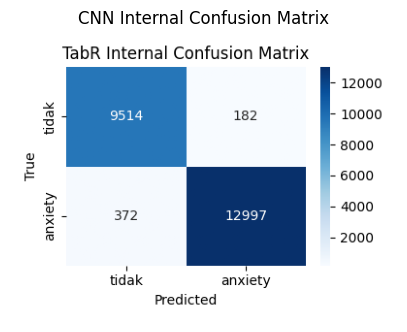

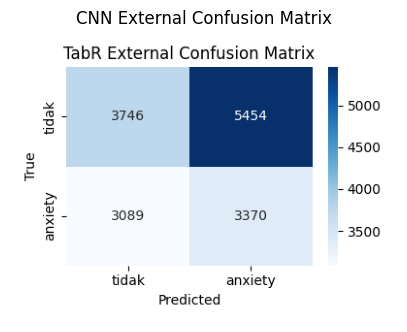


=== INTERNAL CLASSIFICATION REPORT (PERCENT) ===
Class         Precision     Recall         F1   Support
tidak            96.24%     98.12%     97.17%      9696
anxiety          98.62%     97.22%     97.91%     13369
Accuracy: 97.60%

=== EXTERNAL CLASSIFICATION REPORT (PERCENT) ===
Class         Precision     Recall         F1   Support
tidak            54.81%     40.72%     46.72%      9200
anxiety          38.19%     52.18%     44.10%      6459
Accuracy: 45.44%


In [12]:
visualize_results(
    "tabr_experiment/before_flatten/"
)

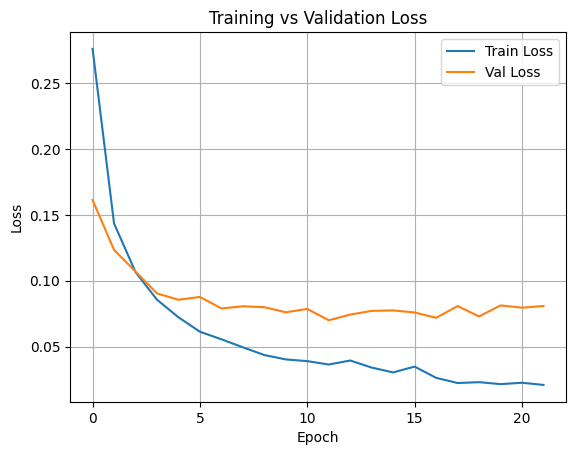

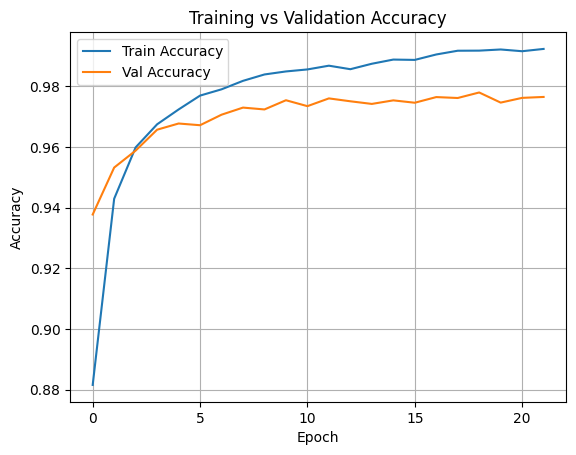

In [13]:
plot_lightning_metrics(
    "./tabr_experiment/before_flatten/tabr_logs/version_9/metrics.csv"
)

In [1]:
from joblib import load

out_dir = "tabr_experiment/before_flatten"

imputer = load(f"{out_dir}/imputer.joblib")
scaler = load(f"{out_dir}/scaler.joblib")
feature_cols = load(f"{out_dir}/feature_cols.joblib")

ctx_train_X, ctx_train_y = load(f"{out_dir}/context.joblib")

ctx_train_X = ctx_train_X.to("cuda")
ctx_train_y = ctx_train_y.to("cuda")


In [6]:
model = LitTabR.load_from_checkpoint(
    "tabr_experiment/before_flatten/tabr_model.ckpt"
).to("cuda")

In [ ]:
model.set_preprocessor(
    imputer=imputer,
    scaler=scaler,
    feature_cols=feature_cols
)

model.set_default_context(
    ctx_train_X,
    ctx_train_y
)

model.eval()

assert model.feature_cols is not None
assert model.imputer is not None
assert model.scaler is not None

In [19]:
model.eval()

LitTabR(
  (encoder): TabREncoder(
    (linear): Linear(in_features=392, out_features=128, bias=True)
    (blocks): ModuleList()
  )
  (WK): Linear(in_features=128, out_features=128, bias=False)
  (WY): Embedding(2, 128)
  (T): ValueCorrection(
    (fc1): Linear(in_features=128, out_features=128, bias=False)
    (fc2): Linear(in_features=128, out_features=128, bias=False)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (predictor): Sequential(
    (0): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=128, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=128, out_features=128, bias=True)
  )
  (head): Linear(in_features=128, out_features=2, bias=True)
  (loss_fn): CrossEntropyLoss()
)

In [ ]:
import pandas as pd

csv_path = "./testing/features/before/anxiety/ananda_satria_putra_nugraha_1765167942203/poc_abs_flatten.xlsx"
df = pd.read_excel(csv_path)

pred, prob = model.predict_from_df(df, threshold=0.6)
df["pred"] = pred
df["prob_anxiety"] = prob
df["pred"].value_counts(normalize=True)

pred
1    0.680593
0    0.319407
Name: proportion, dtype: float64

In [ ]:
TARGET_FILE = "poc_abs_flatten.xlsx"
root_dir = "./testing/features/before"

In [ ]:
import os
import pandas as pd

results = []

for true_label in ["tidak", "anxiety"]:
    label_dir = os.path.join(root_dir, true_label)

    for subject_name in os.listdir(label_dir):
        subject_dir = os.path.join(label_dir, subject_name)
        if not os.path.isdir(subject_dir):
            continue

        file_path = os.path.join(subject_dir, TARGET_FILE)

        if not os.path.exists(file_path):
            continue

        # =========================
        # LOAD FILE TARGET SAJA
        # =========================
        df = pd.read_excel(file_path)

        # =========================
        # PREDICT FRAME-LEVEL
        # =========================
        pred, prob = model.predict_from_df(df, threshold=0.5)
        df["pred"] = pred
        df["prob_anxiety"] = prob

        # =========================
        # SUBJECT-LEVEL SUMMARY
        # =========================
        summary = {
            "subject": subject_name,
            "true_label": true_label,
            "n_frames": len(df),
            "mean_prob": df["prob_anxiety"].mean(),
            "std_prob": df["prob_anxiety"].std(),
            "pct_anxiety": df["pred"].mean(),
            "pct_tidak": 1.0 - df["pred"].mean(),

        }

        results.append(summary)
        print(f"✔ Processed {subject_name}")


Processing najla_nuricia_laudy_1766477470327...
✔ Processed najla_nuricia_laudy_1766477470327


In [25]:
subject_table = pd.DataFrame(results)

subject_table["subject_pred"] = (subject_table["mean_prob"] > 0.5).astype(int)
label_map = {0: "tidak", 1: "anxiety"}
subject_table["subject_label"] = subject_table["subject_pred"].map(label_map)
subject_table["confidence"] = (subject_table["mean_prob"] - 0.5).abs()

subject_table

,subject,true_label,n_frames,mean_prob,std_prob,pct_anxiety,pct_tidak,subject_pred,subject_label,confidence
0,najla_nuricia_laudy_1766477470327,tidak,742,0.703619,0.376282,0.71159,0.28841,1,anxiety,0.203619
